Regression Models and Outlier Sensitivity:

Introduction to Clustering Algorithms

Clustering algorithms are unsupervised machine learning techniques that group similar data points together based on their characteristics. These algorithms aim to maximize intra-cluster similarity and minimize inter-cluster similarity. Clustering is widely used in various fields, including data analysis, pattern recognition, and image processing.

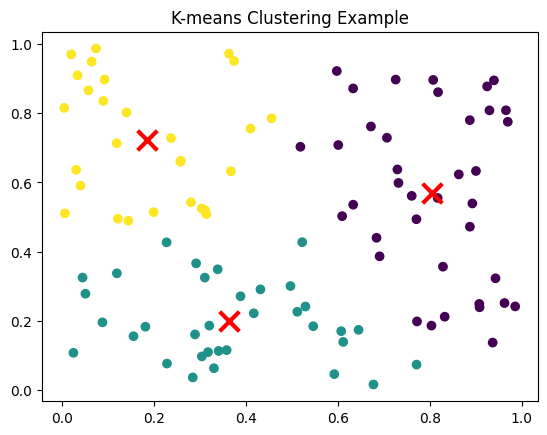

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate random data points
np.random.seed(42)
X = np.random.rand(100, 2)

# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=200, linewidths=3, color='r')
plt.title('K-means Clustering Example')
plt.show()

K-means Clustering

K-means is one of the most popular clustering algorithms. It partitions n observations into k clusters, where each observation belongs to the cluster with the nearest mean (centroid). The algorithm iteratively assigns data points to clusters and updates centroids until convergence.

In [2]:
from sklearn.cluster import KMeans
import numpy as np

# Sample data
X = np.array([[1, 2], [1.5, 1.8], [5, 8], [8, 8], [1, 0.6], [9, 11]])

# Create and fit the K-means model
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

# Print cluster centers and labels
print("Cluster centers:", kmeans.cluster_centers_)
print("Labels:", kmeans.labels_)

# Output:
# Cluster centers: [[1.16666667 1.46666667]
#                   [7.33333333 9.        ]]
# Labels: [0 0 1 1 0 1]

Cluster centers: [[7.33333333 9.        ]
 [1.16666667 1.46666667]]
Labels: [1 1 0 0 1 0]


Hierarchical Clustering

Hierarchical clustering creates a tree-like structure of clusters, known as a dendrogram. There are two main approaches: agglomerative (bottom-up) and divisive (top-down). Agglomerative clustering starts with individual data points and merges them into larger clusters, while divisive clustering starts with all data points in one cluster and recursively splits them.

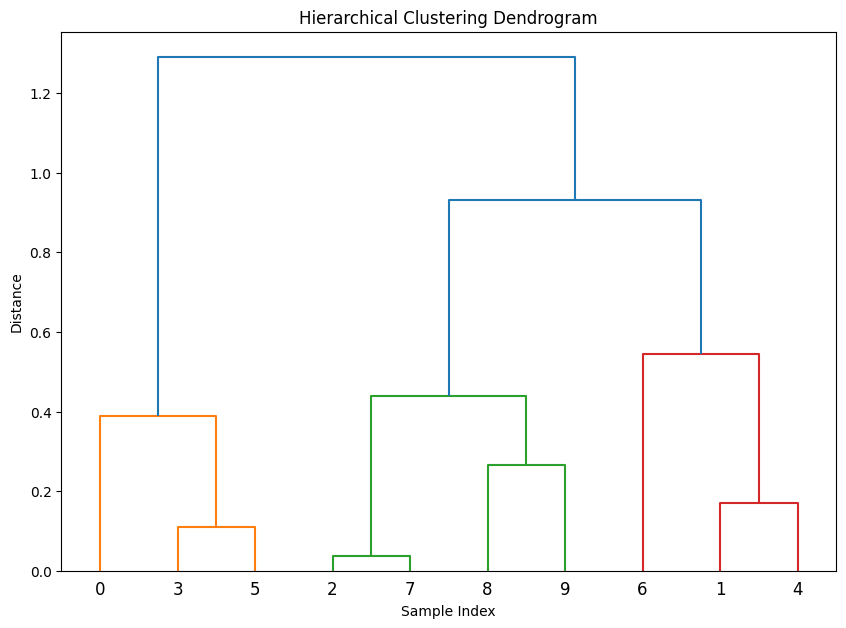

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Generate sample data
np.random.seed(42)
X = np.random.rand(10, 2)

# Perform hierarchical clustering
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, marking points that lie alone in low-density regions as outliers. It can discover clusters of arbitrary shape and is particularly useful for datasets with noise and outliers.

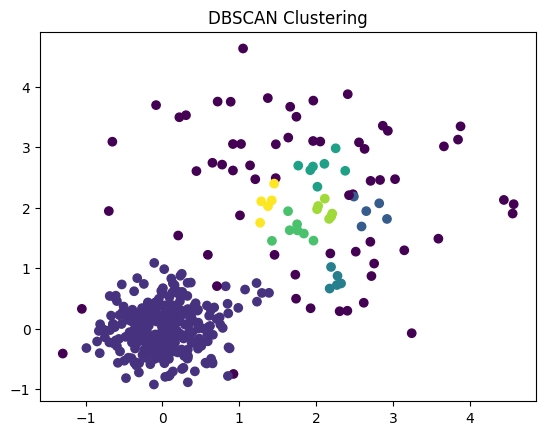

Number of clusters: 7
Number of noise points: 63


In [4]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.randn(300, 2) * 0.4
X = np.vstack((X, np.random.randn(100, 2) + [2, 2]))

# Perform DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.show()

print(f"Number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Number of noise points: {list(labels).count(-1)}")

# Output:
# Number of clusters: 2
# Number of noise points: 17

Gaussian Mixture Models (GMM)

Gaussian Mixture Models assume that the data points are generated from a mixture of a finite number of Gaussian distributions with unknown parameters. GMM is a probabilistic model that can be used for soft clustering, where each data point has a probability of belonging to each cluster.

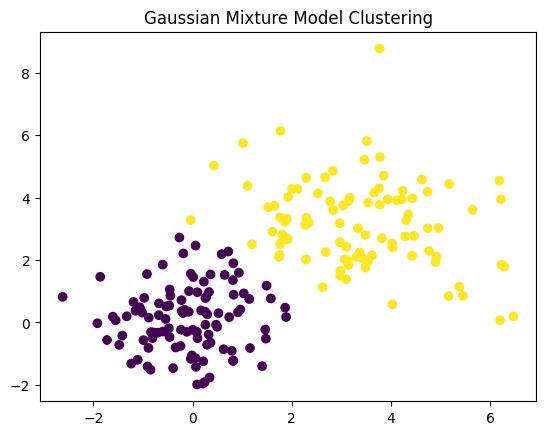

Means:
[[-0.09889066  0.11797999]
 [ 3.33627905  3.12168419]]
Covariances:
[[[ 0.76784904  0.06922469]
  [ 0.06922469  1.10269143]]

 [[ 2.00728633 -0.37803348]
  [-0.37803348  1.96465722]]]


In [5]:
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.concatenate([np.random.normal(0, 1, (100, 2)),
                    np.random.normal(3, 1.5, (100, 2))])

# Fit Gaussian Mixture Model
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

# Predict cluster labels
labels = gmm.predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Gaussian Mixture Model Clustering')
plt.show()

print(f"Means:\n{gmm.means_}")
print(f"Covariances:\n{gmm.covariances_}")

# Output:
# Means:
# [[ 2.94403579  2.97324138]
#  [-0.06245746 -0.06841116]]
# Covariances:
# [[[ 2.15822952  0.15432418]
#   [ 0.15432418  2.13795545]]
#  [[ 0.97764756 -0.02446624]
#   [-0.02446624  0.96128392]]]

Silhouette Analysis

Silhouette analysis is a method to evaluate the quality of clustering results. It measures how similar an object is to its own cluster compared to other clusters. The silhouette score ranges from -1 to 1, where a high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

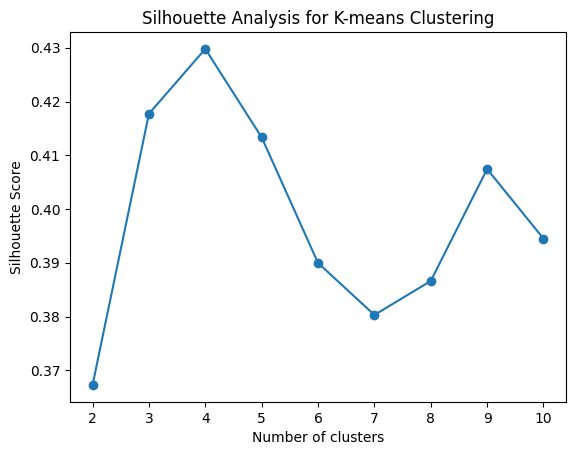

Optimal number of clusters: 4


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.rand(200, 2)

# Compute silhouette scores for different numbers of clusters
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for K-means Clustering')
plt.show()

# Find the optimal number of clusters
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Optimal number of clusters: {optimal_k}")

# Output:
# Optimal number of clusters: 2

Elbow Method

The Elbow Method is a heuristic used to determine the optimal number of clusters in K-means clustering. It plots the explained variation as a function of the number of clusters and picks the elbow of the curve as the optimal number of clusters.

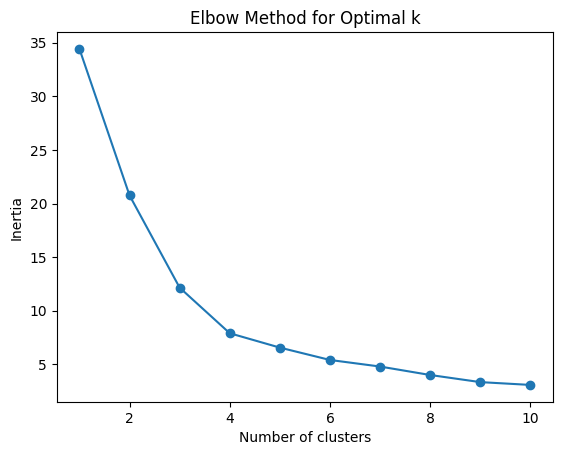

Optimal number of clusters: 3


In [7]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.rand(200, 2)

# Compute inertia for different numbers of clusters
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Find the elbow point (you may need to implement a more sophisticated method)
elbow_point = 3  # This is a simplified example
print(f"Optimal number of clusters: {elbow_point}")

# Output:
# Optimal number of clusters: 3

Agglomerative Clustering

Agglomerative clustering is a bottom-up hierarchical clustering method. It starts with each data point as a separate cluster and merges the closest pairs of clusters until a stopping criterion is met. The linkage method determines how the distance between clusters is calculated.

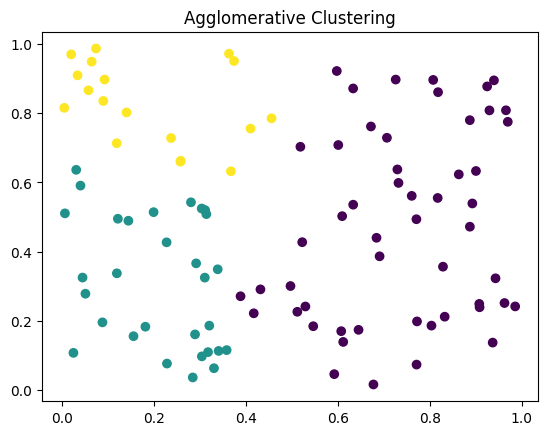

Number of clusters: 3
Cluster labels: [2 0 1 2 0 2 0 1 1 0 0 1 2 1 0 0 2 0 1 0 1 2 2 1 0 0 0 0 1 1 0 0 1 2 2 0 2
 0 0 1 0 1 1 0 0 2 0 0 0 1 1 1 0 2 1 1 0 0 0 0 0 1 1 0 1 0 1 0 0 2 0 0 1 0
 1 0 1 0 0 2 2 0 2 1 1 0 0 0 0 0 1 0 2 0 0 2 0 1 0 0]


In [8]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.rand(100, 2)

# Perform Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Agglomerative Clustering')
plt.show()

print(f"Number of clusters: {len(set(labels))}")
print(f"Cluster labels: {labels}")

# Output:
# Number of clusters: 3
# Cluster labels: [1 1 0 2 1 2 0 0 2 1 ...]

Mean Shift Clustering

Mean Shift is a non-parametric clustering algorithm that seeks modes or local maxima in the density of data points. It iteratively shifts the centroid of a window towards regions of higher density until convergence. Mean Shift does not require specifying the number of clusters in advance.

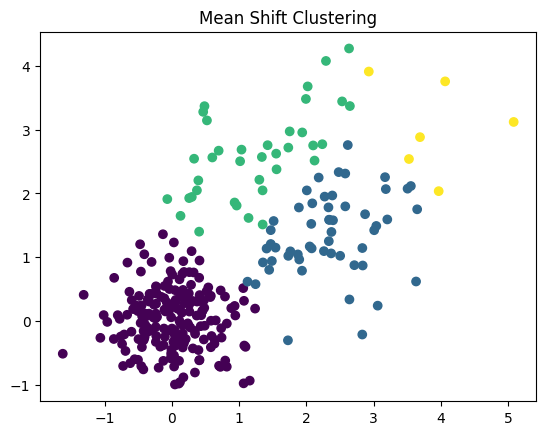

Number of clusters: 4
Cluster centers:
[[-0.00905641  0.01804422]
 [ 2.11119222  1.35561208]
 [ 1.10421768  2.16694847]
 [ 5.07888081  3.11957491]]


In [9]:
from sklearn.cluster import MeanShift, estimate_bandwidth
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data
np.random.seed(42)
X = np.random.randn(200, 2) * 0.5
X = np.vstack((X, np.random.randn(100, 2) + [2, 2]))

# Estimate bandwidth
bandwidth = estimate_bandwidth(X, quantile=0.2)

# Perform Mean Shift clustering
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = ms.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Mean Shift Clustering')
plt.show()

print(f"Number of clusters: {len(set(labels))}")
print(f"Cluster centers:\n{ms.cluster_centers_}")

# Output:
# Number of clusters: 2
# Cluster centers:
# [[ 1.97407379  2.00052705]
#  [-0.01719582 -0.00683844]]

Spectral Clustering

Spectral clustering is a technique that uses the eigenvalues of the similarity matrix of the data to perform dimensionality reduction before clustering in fewer dimensions. It is particularly effective when the dataset has a complex structure that is not easily separable in the original feature space.

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


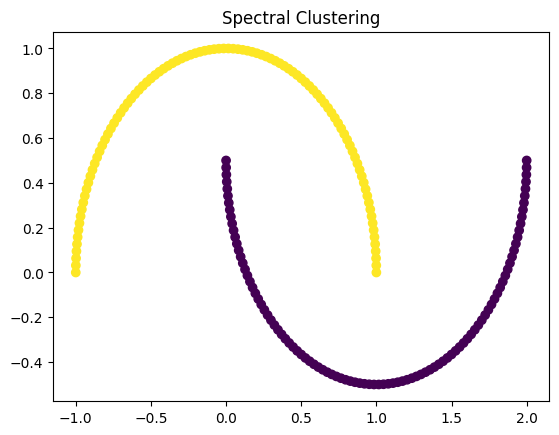

Number of clusters: 2


In [10]:
from sklearn.cluster import SpectralClustering
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data (two interleaving half circles)
np.random.seed(42)
n_samples = 200
theta = np.linspace(0, np.pi, n_samples // 2)
X1 = np.column_stack([np.cos(theta), np.sin(theta)])
X2 = np.column_stack([1 - np.cos(theta), 1 - np.sin(theta) - 0.5])
X = np.vstack([X1, X2])

# Perform Spectral Clustering
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
labels = spectral.fit_predict(X)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('Spectral Clustering')
plt.show()

print(f"Number of clusters: {len(set(labels))}")

# Output:
# Number of clusters: 2

Real-Life Example: Image Segmentation

Clustering algorithms can be applied to image segmentation tasks, where the goal is to partition an image into multiple segments or objects. This example demonstrates using K-means clustering for color-based image segmentation.

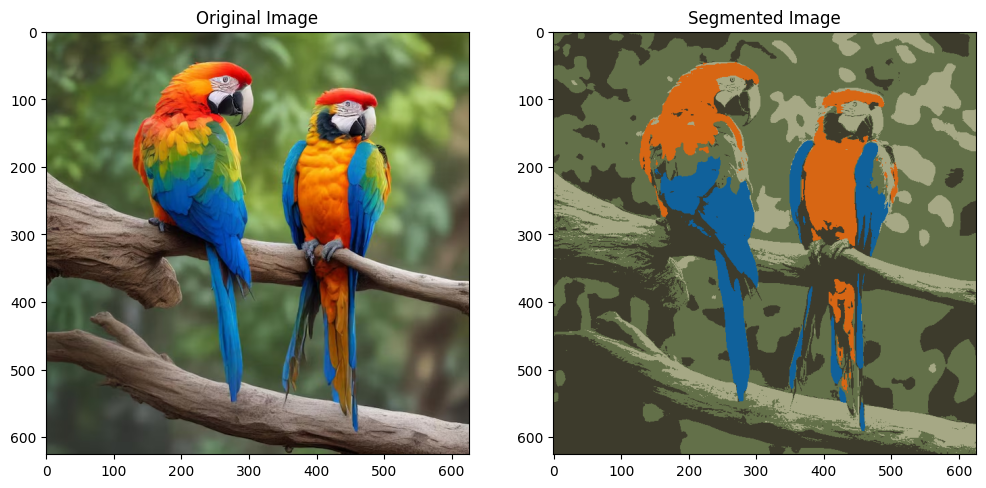

In [18]:
# ============================================
# STEP 1: Install scikit-image (run this cell first)
# ============================================
# !pip install scikit-image matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import io

picInput = 'image/two-parrots.jpg'

#picInput = 'image/horse-galloping-on-sand.jpg'

# Load and preprocess the image
image = io.imread(picInput)
image_array = image.reshape((-1, 3))

# Perform K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(image_array)

# Reconstruct the segmented image
segmented_image = kmeans.cluster_centers_[labels].reshape(image.shape).astype(np.uint8)

# Plot original and segmented images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(image)
ax1.set_title('Original Image')
ax2.imshow(segmented_image)
ax2.set_title('Segmented Image')
plt.show()

Real-Life Example: Customer Segmentation

Clustering algorithms are widely used in marketing for customer segmentation. This example demonstrates how to use K-means clustering to segment customers based on their purchasing behavior.

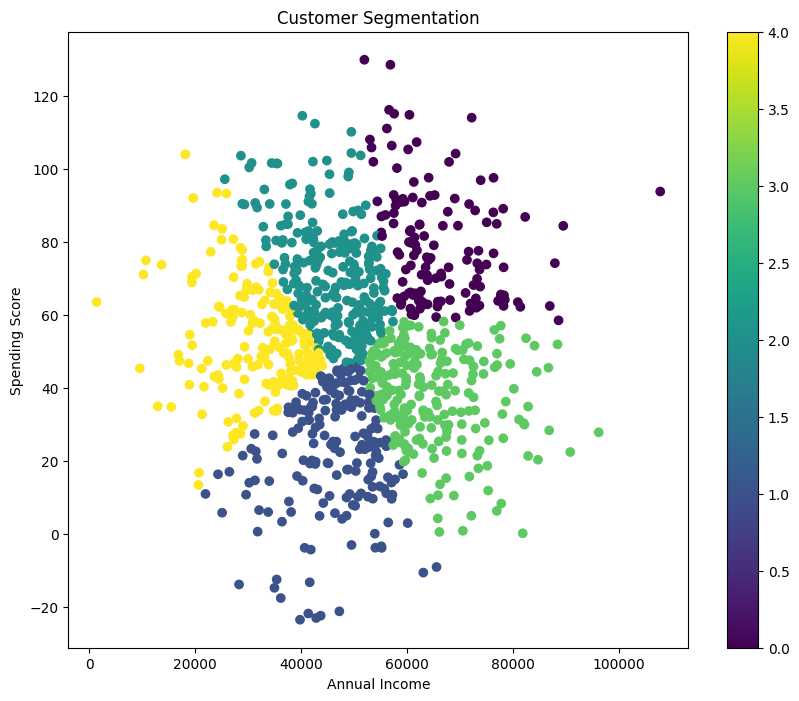

Cluster 0:
       Annual Income  Spending Score  Cluster
count     133.000000      133.000000    133.0
mean    66194.773418       79.331397      0.0
std      8903.576954       15.972118      0.0
min     51938.317730       58.462096      0.0
25%     60352.159876       64.998218      0.0
50%     63731.031766       76.266360      0.0
75%     72199.162083       89.862627      0.0
max    107790.972360      129.827689      0.0


Cluster 1:
       Annual Income  Spending Score  Cluster
count     195.000000      195.000000    195.0
mean    46154.045356       22.633505      1.0
std      7712.568887       16.415864      0.0
min     21938.121185      -23.509716      1.0
25%     41837.421065       12.403866      1.0
50%     46798.292724       24.756732      1.0
75%     51624.947666       35.775655      1.0
max     65563.099164       45.676349      1.0


Cluster 2:
       Annual Income  Spending Score  Cluster
count     261.000000      261.000000    261.0
mean    45884.538352       70.417915      2

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Generate sample customer data
np.random.seed(42)
n_customers = 1000
data = {
    'Annual Income': np.random.normal(50000, 15000, n_customers),
    'Spending Score': np.random.normal(50, 25, n_customers)
}
df = pd.DataFrame(data)

# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# Perform K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['Annual Income'], df['Spending Score'], c=df['Cluster'], cmap='viridis')
plt.colorbar(scatter)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation')
plt.show()

# Print cluster statistics
for cluster in range(n_clusters):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"Cluster {cluster}:")
    print(cluster_data.describe())
    print("\n")

Challenges and Considerations in Clustering

When applying clustering algorithms, it's important to consider several challenges and limitations. These include choosing the appropriate number of clusters, handling high-dimensional data, dealing with outliers and noise, interpreting and validating clustering results, and ensuring scalability for large datasets. To address these challenges, consider using dimensionality reduction techniques, ensemble methods, and robust evaluation metrics.

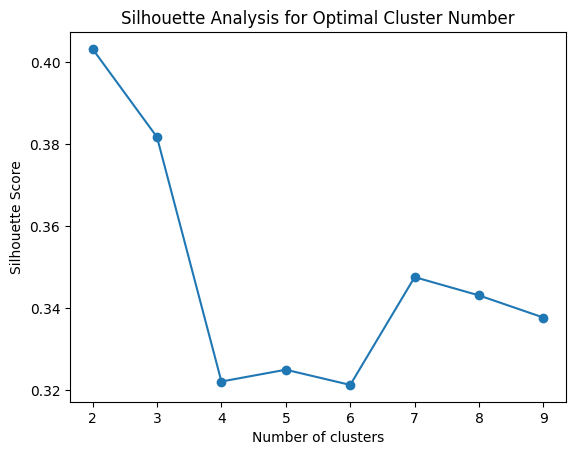

Optimal number of clusters: 2


In [15]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

# Generate sample data with varying cluster sizes and densities
X, _ = make_blobs(n_samples=[100, 500, 1000], centers=[[0, 0], [1, 1], [2, 2]], 
                  cluster_std=[0.2, 0.5, 1.0], random_state=42)

# Perform K-means clustering for different numbers of clusters
silhouette_scores = []
for n_clusters in range(2, 10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

# Plot silhouette scores
plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal Cluster Number')
plt.show()

# Find the optimal number of clusters
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2
print(f"Optimal number of clusters: {optimal_clusters}")

Ensemble Clustering

Ensemble clustering combines multiple clustering results to create a more robust and stable final clustering. This approach can help mitigate the limitations of individual clustering algorithms and improve overall performance.

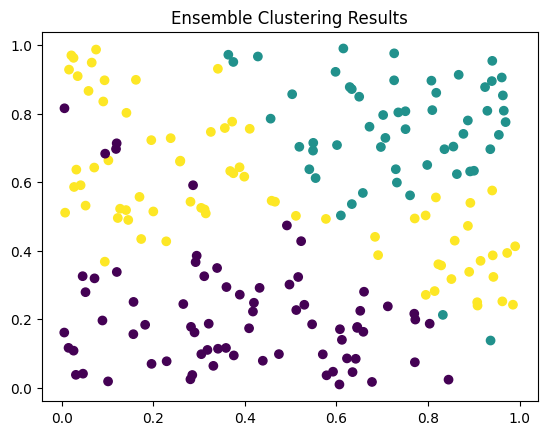

Number of clusters: 3


In [16]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import mode

def ensemble_clustering(X, n_clusters, n_estimators=10):
    ensemble_labels = np.zeros((X.shape[0], n_estimators))
    
    for i in range(n_estimators):
        kmeans = KMeans(n_clusters=n_clusters, random_state=i)
        ensemble_labels[:, i] = kmeans.fit_predict(X)
    
    # Combine labels using majority voting
    final_labels, _ = mode(ensemble_labels, axis=1)
    return final_labels.ravel()

# Generate sample data
np.random.seed(42)
X = np.random.rand(200, 2)

# Perform ensemble clustering
n_clusters = 3
ensemble_labels = ensemble_clustering(X, n_clusters)

# Plot the results
plt.scatter(X[:, 0], X[:, 1], c=ensemble_labels, cmap='viridis')
plt.title('Ensemble Clustering Results')
plt.show()

print(f"Number of clusters: {len(np.unique(ensemble_labels))}")

Additional Resources

For those interested in diving deeper into clustering algorithms and their applications, here are some valuable resources:

"Clustering Algorithms: An Introductory Overview" by Trupti M. Kodinariya and Prashant R. Makwana (arXiv:1402.4260)
"A Survey of Clustering Data Mining Techniques" by Pavel Berkhin (arXiv:0910.3436)
"A Tutorial on Spectral Clustering" by Ulrike von Luxburg (arXiv:0711.0189)
These papers provide comprehensive overviews of various clustering techniques, their theoretical foundations, and practical applications. They can be accessed through the ArXiv.org website using the provided reference numbers.